Do students who spend more time on social websites sleep fewer hours on school nights?
This is an observational study because I can only show an association and not that one causes the other.

In [4]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
teen = pd.read_csv("CensusAtSchool.csv")
teen

,Country,Region,DataYear,ClassGrade,Gender,Ageyears,Handed,Height_cm,Footlength_cm,Armspan_cm,...,Watching_TV_Hours,Paid_Work_Hours,Work_At_Home_Hours,Schoolwork_Pressure,Planned_Education_Level,Favorite_Music,Superpower,Preferred_Status,Role_Model_Type,Charity_Donation
0,USA,SC,2013,11,Male,17.0,Right-Handed,180,26,180,...,2,20,10,NaN,Graduate degree,Country,Invisibility,Rich,Relative,Health
1,USA,CA,2016,12,Female,17.0,Right-Handed,170,24,162.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USA,WA,2025,12,Male,17.0,Right-Handed,182,26.5,176,...,0,0,3,Some,High school,Rock and roll,Freeze time,Healthy,Other,Other
3,USA,TN,2015,12,Male,17.0,Right-Handed,180,30,184,...,5,35,5,Very little,Graduate degree,Country,Fly,Happy,Friend,Other
4,USA,MA,2019,11,Male,16.0,Right-Handed,174.5,27,182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,USA,WA,2019,12,Female,17.0,Right-Handed,55,9.5,18,...,0,0,2,Some,Other,Rap/Hip hop,Fly,Healthy,Musician or singer,Health
496,USA,IA,2021,12,Male,18.0,Right-Handed,176,26,175,...,0,13,3,A lot,Graduate degree,Rock and roll,Fly,Happy,Friend,Health
497,USA,NC,2022,12,Female,17.0,Right-Handed,162.5,23.8,91.44,...,7 hrs,30 hr,0,Very little,Other,Rap/Hip hop,Invisibility,Happy,Friend,"Wildlife, animals"
498,USA,ID,2024,10,Male,15.0,Right-Handed,165,25,172,...,1,0,10,Some,Some college,Rock and roll,Freeze time,Rich,Other,"Wildlife, animals"


In [5]:
screen_time = teen["Social_Websites_Hours"]
screen_time

0         1
1       NaN
2        20
3         1
4       NaN
       ... 
495       2
496       1
497    24/7
498       5
499     0.5
Name: Social_Websites_Hours, Length: 500, dtype: str

In [6]:
sleep_time = teen["Sleep_Hours_Schoolnight"]
sleep_time

0        8
1      NaN
2        7
3        6
4      NaN
      ... 
495      6
496      7
497      6
498      9
499      7
Name: Sleep_Hours_Schoolnight, Length: 500, dtype: str

In [7]:
def to_hours(v):
    """Turn messy survey entries like '45min', '6hrs', '6-8', '6 1/2' into hours."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    try:
        return float(s)
    except ValueError:
        pass
    if s in {"24/7", "20+", "7/6"}:          # ambiguous or open-ended
        return np.nan
    m = re.fullmatch(r"(\d+(?:\.\d+)?)\s*min", s)
    if m:
        return float(m.group(1)) / 60
    m = re.fullmatch(r"(\d+(?:\.\d+)?)\s*(?:h|hr|hrs|hour|hours)", s)
    if m:
        return float(m.group(1))
    m = re.fullmatch(r"(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)", s)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = re.fullmatch(r"(\d+)\s+1/2", s)
    if m:
        return int(m.group(1)) + 0.5
    return np.nan

In [8]:
df = pd.read_csv("CensusAtSchool.csv")

social = df["Social_Websites_Hours"].map(to_hours).dropna()
social = social[social <= 70]   # remove implausible values (over 10 hrs/day)
len(social)

420

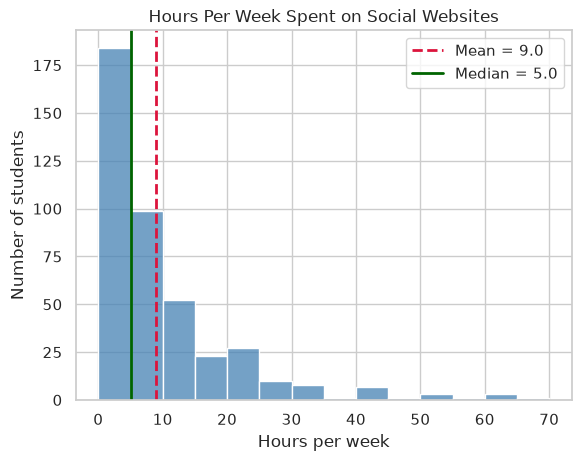

In [11]:
sns.set_theme(style="whitegrid")
ax = sns.histplot(social, bins=14, color="steelblue")
ax.axvline(social.mean(), color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = {social.mean():.1f}")
ax.axvline(social.median(), color="darkgreen", linestyle="-", linewidth=2,
           label=f"Median = {social.median():.1f}")
ax.legend()
ax.set_title("Hours Per Week Spent on Social Websites")
ax.set_xlabel("Hours per week")
ax.set_ylabel("Number of students");

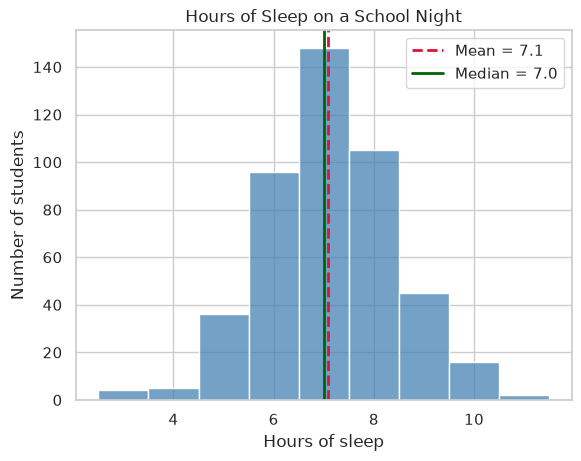

In [13]:
sleep = df["Sleep_Hours_Schoolnight"].map(to_hours).dropna()
sleep = sleep[sleep >= 3]   # remove implausible values (under 3 hours)

sns.set_theme(style="whitegrid")
ax = sns.histplot(sleep, binwidth=1, binrange=(2.5, 11.5), color="steelblue")
ax.axvline(sleep.mean(), color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = {sleep.mean():.1f}")
ax.axvline(sleep.median(), color="darkgreen", linestyle="-", linewidth=2,
           label=f"Median = {sleep.median():.1f}")
ax.legend()
ax.set_title("Hours of Sleep on a School Night")
ax.set_xlabel("Hours of sleep")
ax.set_ylabel("Number of students");

The distibution is strongly right-skewed. You can see that most students are clustered at low values and that the heavy users are the long stretches.

This data shows a weak relationship between the time spent on social websites and the time spend on sleeping on school nights. Students who spend more hours on social websites tend to sleep slightly less, but social website time explains very little of the variation in sleep. Most students spend 10 hours or fewer per week on social websites and sleep 6 to 8 hours.